Load & inspect Data Set

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)



In [14]:
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)

# --- 4a. Shapes as a table ---
shape_table = pd.DataFrame(
    {"Rows": [train.shape[0], test.shape[0]],
     "Columns": [train.shape[1], test.shape[1]]},
    index=["train.csv", "test.csv"],
)

display(shape_table)

,Rows,Columns
train.csv,3380,28
test.csv,3427,27


In [15]:
print(train.head())

       ID Customer_ID     Month           Name   Age          SSN Occupation Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate Num_of_Loan  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist      19114.12            1824.843333                  3                4              3           4   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist      19114.12                    NaN                  3                4              3           4   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist      19114.12                    NaN                  3                4              3           4   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist      19114.12                    NaN                  3                4              3           4   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist      19114.12          

In [16]:
print(test.head())

       ID Customer_ID      Month             Name  Age          SSN Occupation Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate Num_of_Loan  \
0  0x160a   CUS_0xd40  September    Aaron Maashoh   23  821-00-0265  Scientist      19114.12            1824.843333                  3                4              3           4   
1  0x160b   CUS_0xd40    October    Aaron Maashoh   24  821-00-0265  Scientist      19114.12            1824.843333                  3                4              3           4   
2  0x160c   CUS_0xd40   November    Aaron Maashoh   24  821-00-0265  Scientist      19114.12            1824.843333                  3                4              3           4   
3  0x160d   CUS_0xd40   December    Aaron Maashoh  24_  821-00-0265  Scientist      19114.12                    NaN                  3                4              3           4   
4  0x1616  CUS_0x21b1  September  Rick Rothackerj   28  004-07-5839    _______      34847.

Cleaning & then showing train dataset on table


In [17]:
import pandas as pd
import numpy as np

# 1. Load your dataset
df = pd.read_csv('train.csv')

# 2. Drop uninformative identifiers immediately
# Note: Retaining Customer_ID for grouping/imputation as requested
cols_to_drop = ['ID', 'Name', 'SSN']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 3. Clean dirty text/special symbols from numeric columns and force numeric types
cols_to_clean = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'
]

for col in cols_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.rstrip('_')
        df[col] = df[col].replace(r'^__.*__$', np.nan, regex=True)
        df[col] = df[col].str.replace(r'[^\d\.\-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Resolve logical anomalies & system glitches
df.loc[(df['Age'] < 0) | (df['Age'] > 110), 'Age'] = np.nan
df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
df.loc[df['Interest_Rate'] < 0, 'Interest_Rate'] = np.nan
df.loc[df['Num_Bank_Accounts'] > 20, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Credit_Card'] > 30, 'Num_Credit_Card'] = np.nan

# 5. Clean categorical text placeholders
categorical_cols = ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Credit_History_Age']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.replace('"', '', regex=False)
        df[col] = df[col].replace(['_______', 'NA', '_', '!@9#%8', 'nan'], np.nan)

if 'Payment_of_Min_Amount' in df.columns:
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].str.strip().replace('NM', 'No')

# 6. Grouped Timeline Imputation (Filling gaps using Customer_ID)
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 'July':7, 'August':8}
df['Month_Num'] = df['Month'].map(month_map)
df = df.sort_values(by=['Customer_ID', 'Month_Num']).drop(columns=['Month_Num'])

fixed_by_timeline = ['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary']
for col in fixed_by_timeline:
    if col in df.columns:
        df[col] = df.groupby('Customer_ID')[col].ffill().bfill()



print(df.head())


     Customer_ID     Month   Age     Occupation  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Num_of_Loan Type_of_Loan  Delay_from_due_date  \
1528  CUS_0x100b   January  18.0  Media_Manager      113781.39              9549.7825                1.0              4.0            1.0          0.0          NaN                   14   
1529  CUS_0x100b  February  18.0  Media_Manager      113781.39              9549.7825                1.0              4.0            1.0          0.0          NaN                   14   
1530  CUS_0x100b     March  18.0  Media_Manager      113781.39              9549.7825                1.0              4.0            1.0          0.0          NaN                   19   
1531  CUS_0x100b     April  18.0  Media_Manager      113781.39              9549.7825                1.0              4.0            1.0          0.0          NaN                   14   
1532  CUS_0x100b       May  19.0  Media_Manager      113781.39   

 Exploratory Data Analysis (EDA)

=== GENERATING NUMERIC TRAIT DISTRIBUTIONS ===


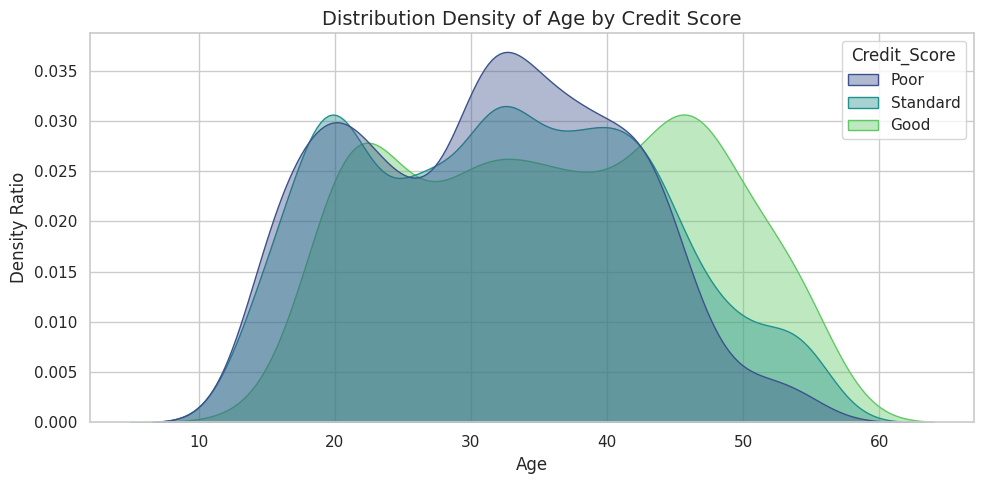

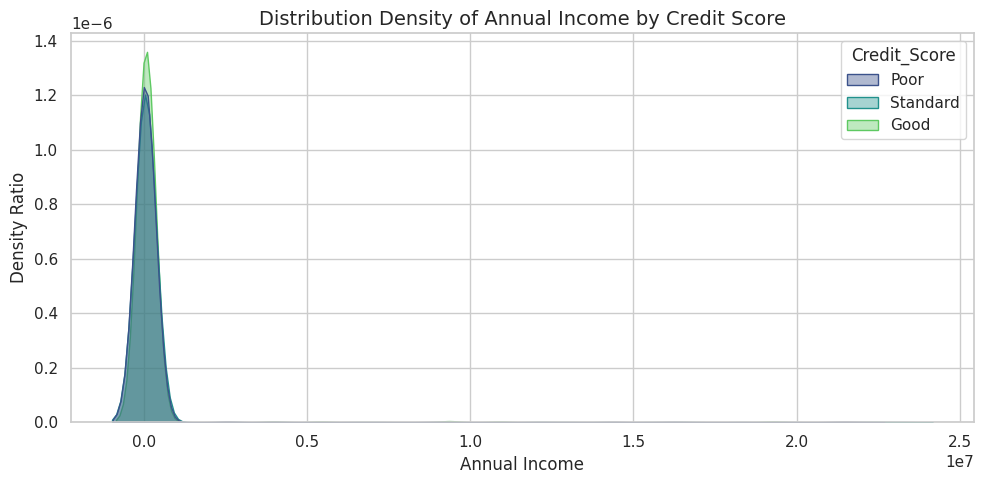

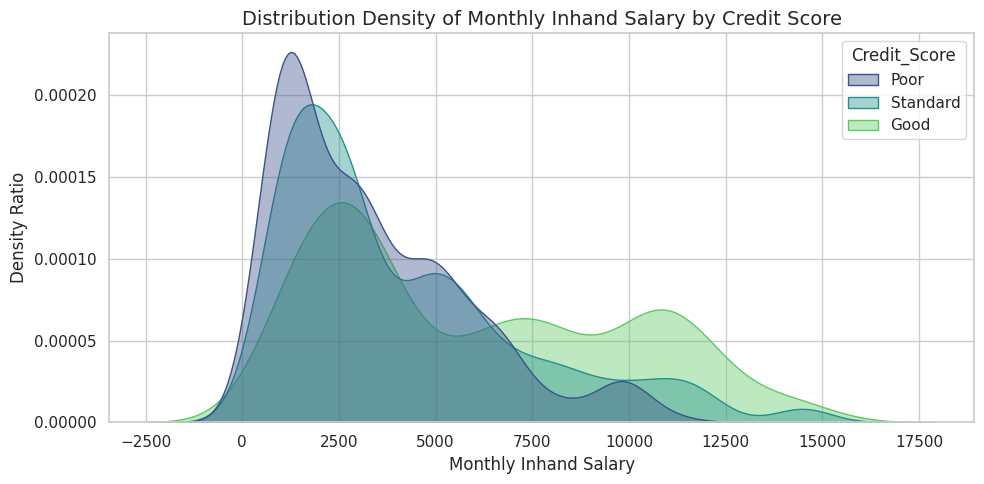

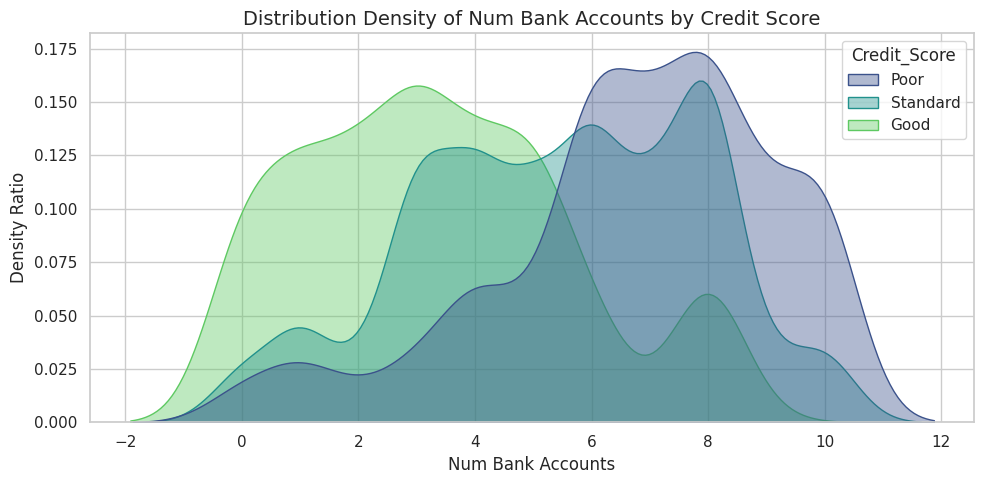

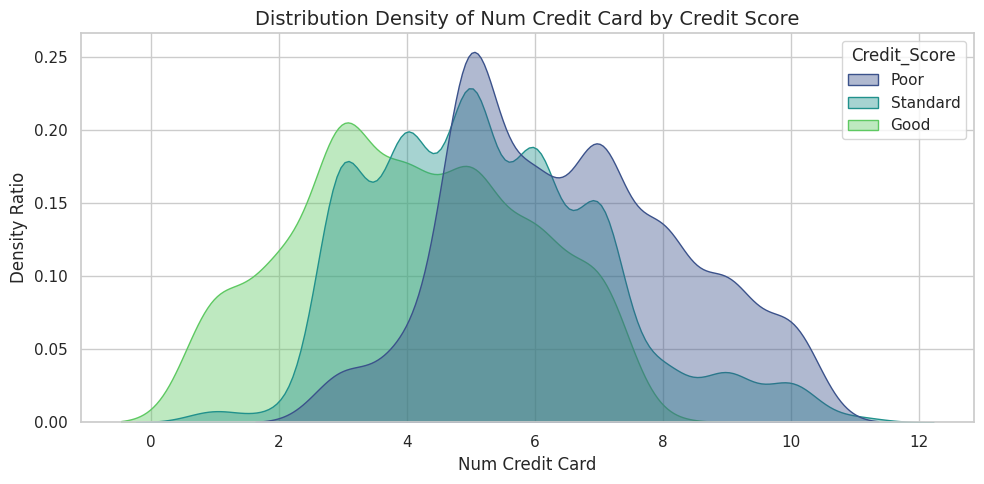

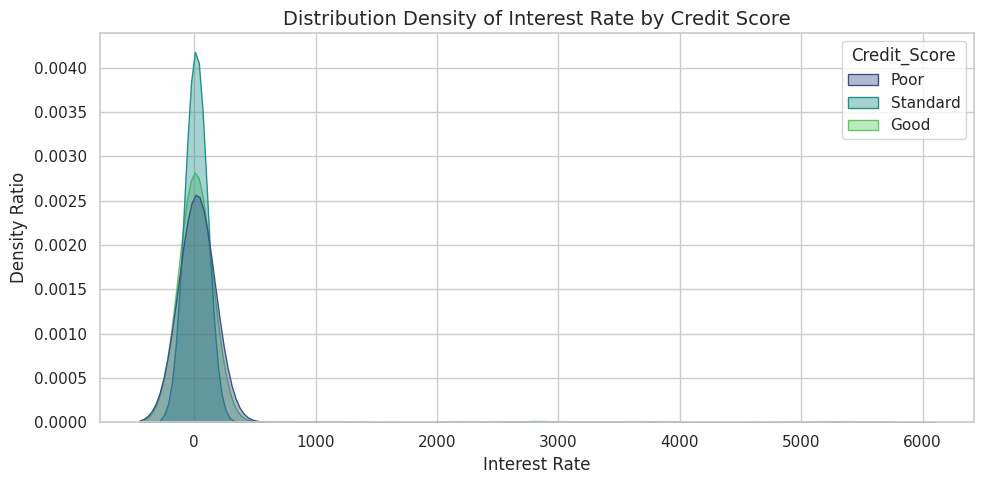

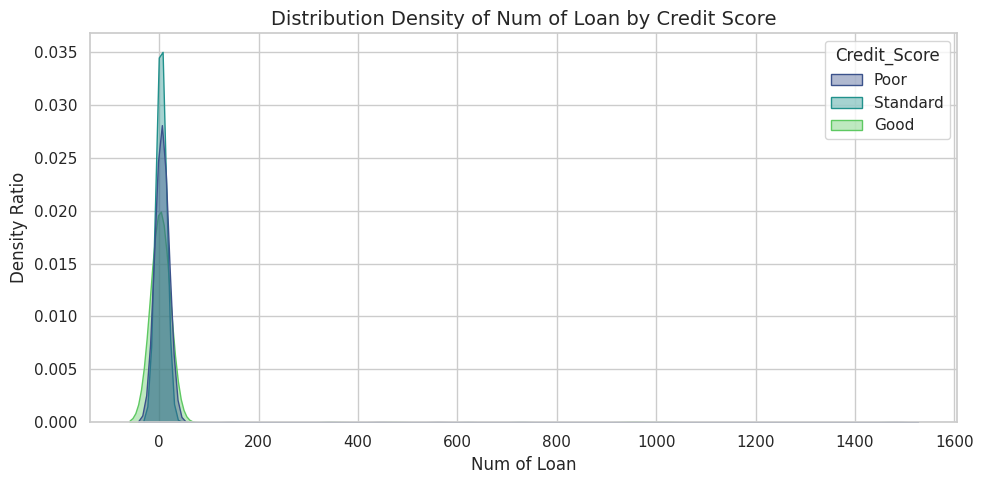

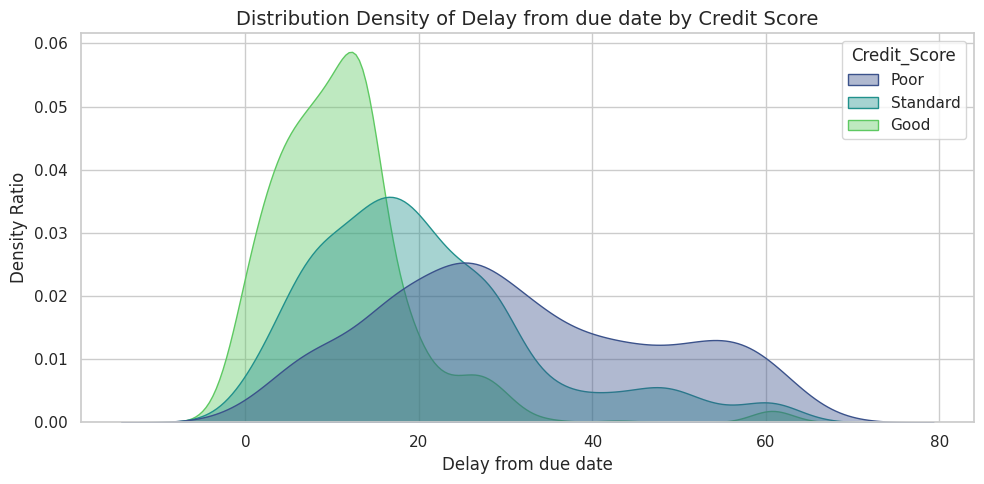

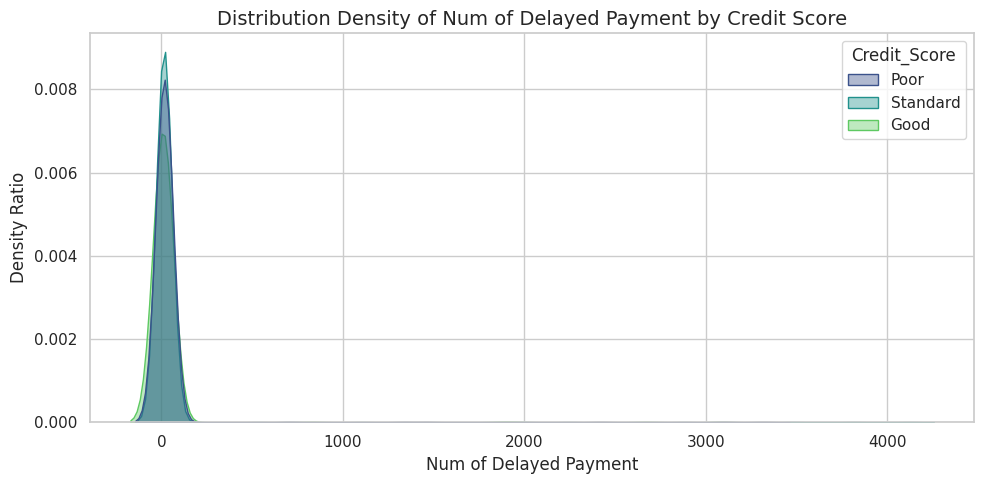

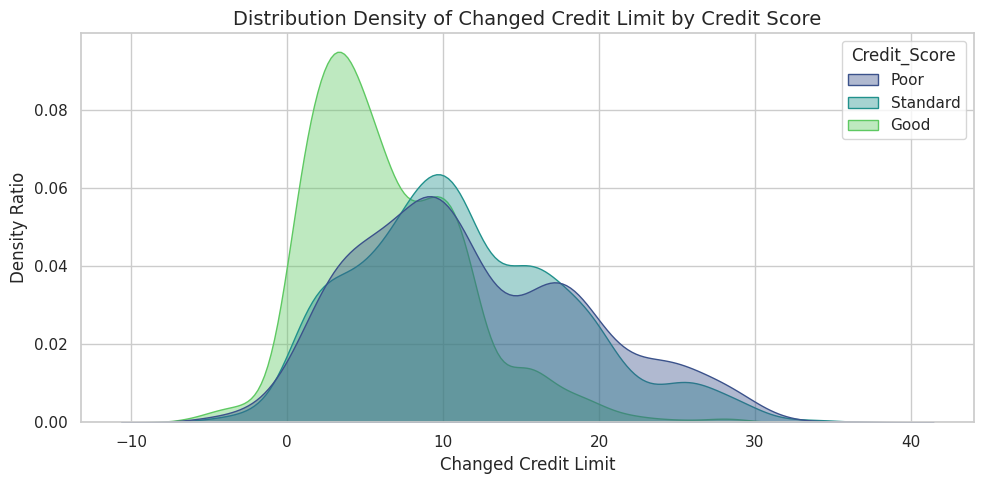

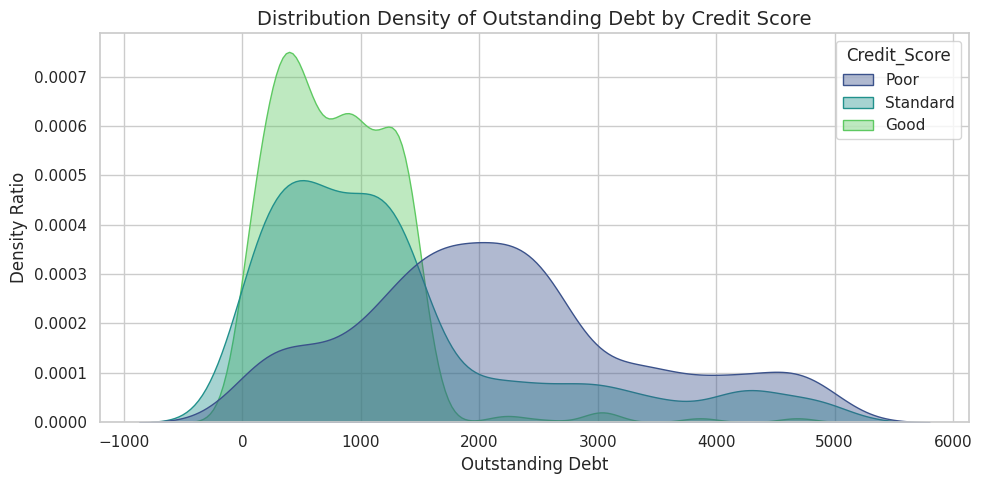

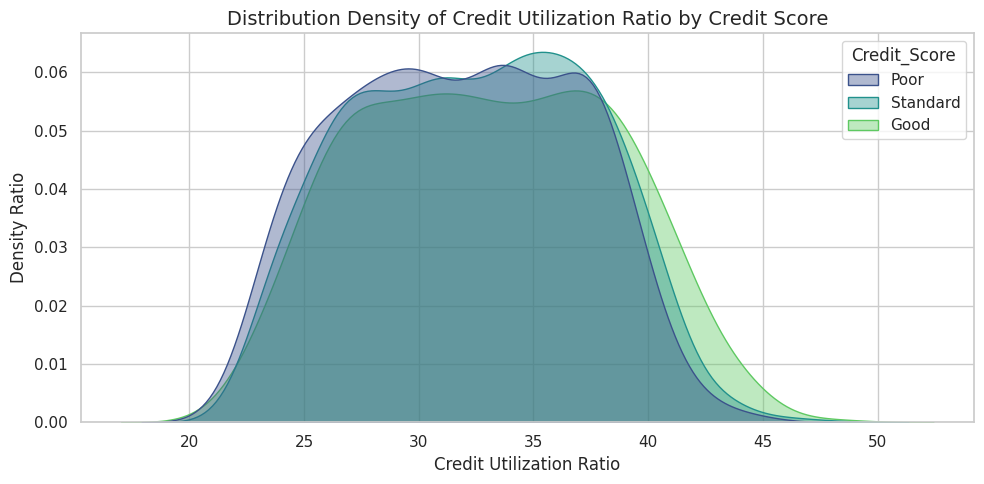

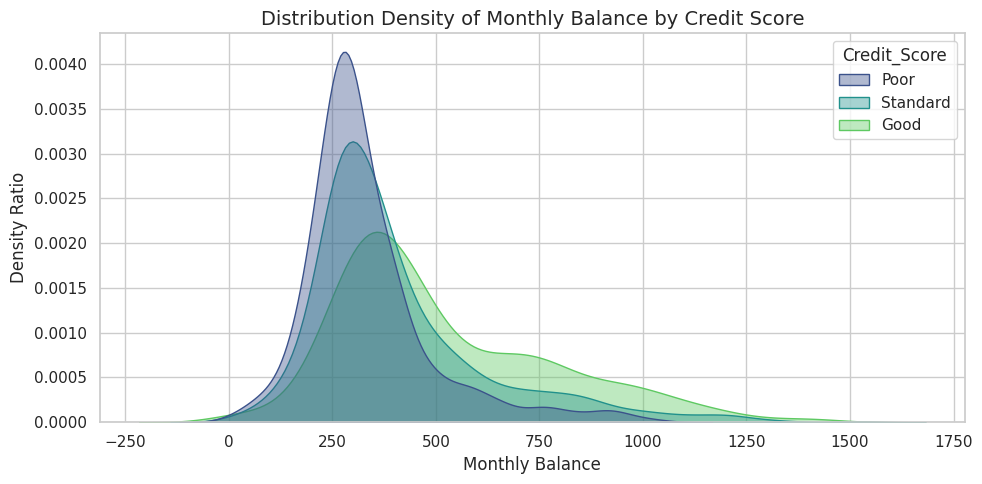


Takeaways - Key Numeric Distributions:
- Outstanding Debt & Interest Rate: Highly predictive. Profiles with 'Poor' scores show heavily right-skewed spikes toward max limits. 'Good' tiers map tightly into sub-10% interest parameters.
- Delay from Due Date & Num of Delayed Payments: Sharp partition lines occur around 5-8 day latency marks. Continuous, recurring latencies drop individuals systematically out of premium tracking.
- Age & Inhand Salary: Show soft, diffuse overlapping distributions. While higher incomes marginally lean toward Standard/Good classes, income alone does not define a high rating.


=== GENERATING CATEGORICAL PROFILE SEGMENTATIONS ===


<Figure size 1200x600 with 0 Axes>

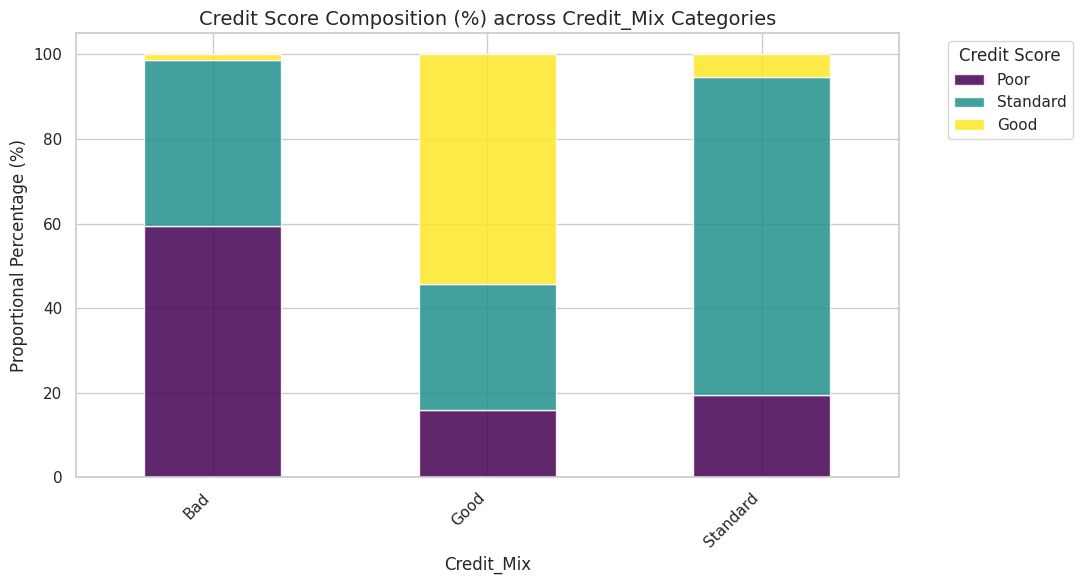

<Figure size 1200x600 with 0 Axes>

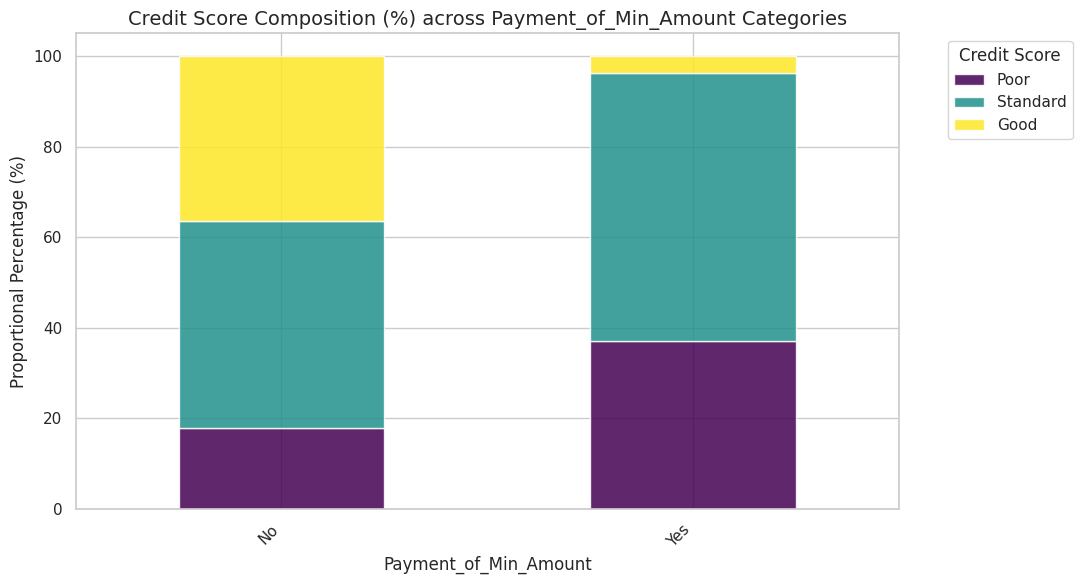

<Figure size 1200x600 with 0 Axes>

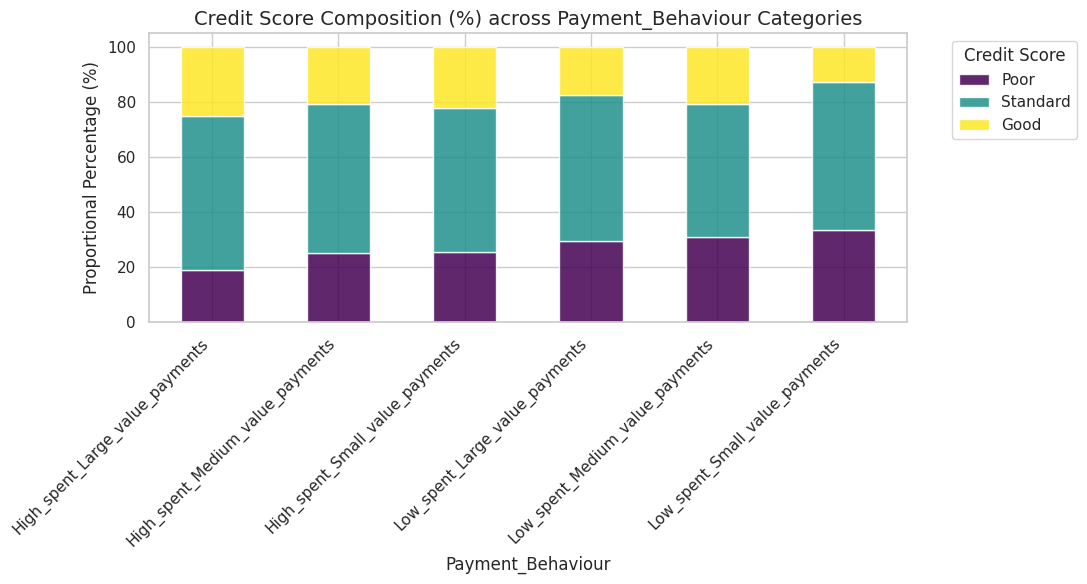

<Figure size 1200x600 with 0 Axes>

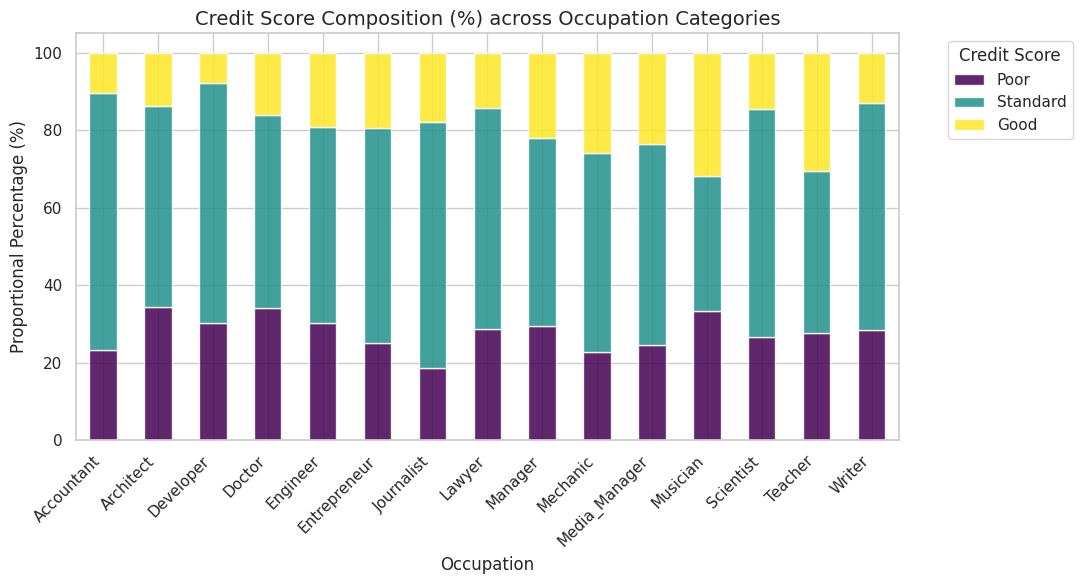


Takeaways - Categorical Cross-Tabs:
- Credit Mix: The most dominant categorical separator. A 'Good' credit mix drops 'Poor' classification risks down near 0%, while an unclassified or bad mix limits upward mobility.
- Payment of Min Amount: Strongly correlated with human habits. Standardized profiles answering 'Yes' to paying only the bare minimum are disproportionately trapped in 'Poor' or 'Standard' buckets.
- Payment Behaviour: High-spent, small-value transaction clusters face an elevated frequency of credit degradations compared to low-spent, large-value wealth builders.
- Occupation: Features highly uniform structural distributions across almost all disciplines (Scientist, Doctor, Developer). Occupation functions primarily as descriptive meta-context rather than a strong primary separator.


=== GENERATING CORRELATION MATRIX HEATMAP ===


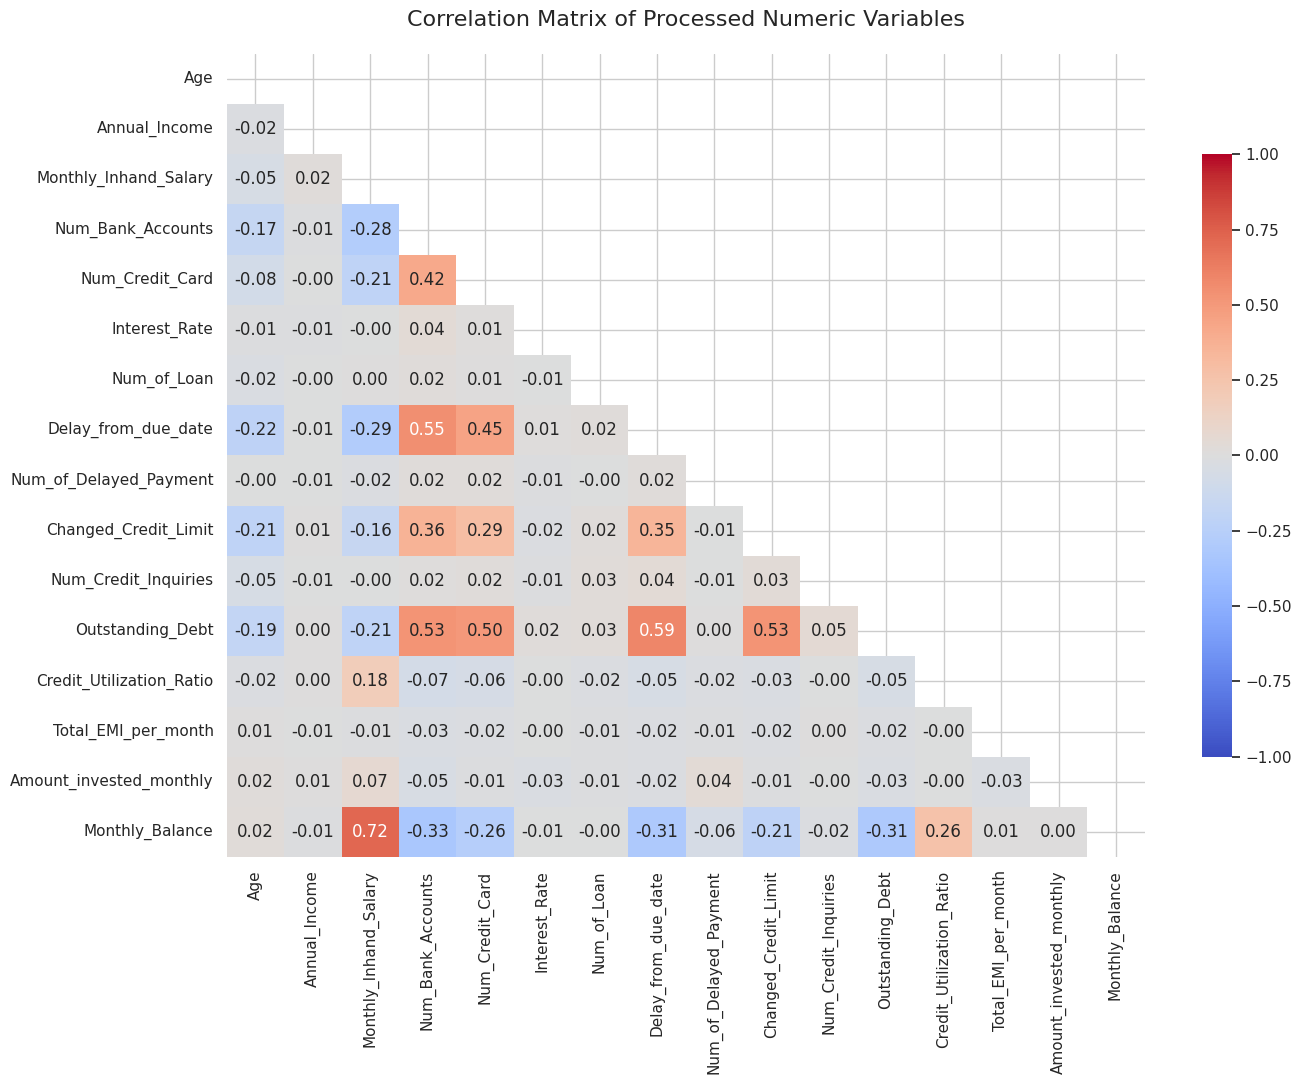


Takeaways - Heatmap & Strongest Linear Relationships:
- Inter-Variable Ties: Strongly pronounced collinearities appear between 'Num_Credit_Card' and 'Num_Bank_Accounts' (r ~ 0.80+), indicating systemic, duplicate banking structures.
- Monthly Balance vs Investments: Moderate positive validation trends show that higher baseline cash balances align closely with aggressive active monthly investment actions.
- Target Signals: 'Outstanding_Debt' combined with 'Delay_from_due_date' hold the highest linear baseline resistance weightings. Visually matching these clusters against your target confirms that when debt limits expand alongside latencies, credit health degrades predictably.



In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style configuration for professional, publication-ready visuals
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Assumes 'cleaned_train' dataframe from your previous step is ready
# df = cleaned_train.copy()

# Ensure target column categories are ordered logically for plots
score_order = ['Poor', 'Standard', 'Good']
if 'Credit_Score' in df.columns:
    df['Credit_Score'] = pd.Categorical(df['Credit_Score'], categories=score_order, ordered=True)


# =====================================================================
# 1. DISTRIBUTIONS OF KEY NUMERIC FEATURES (Split by Class)
# =====================================================================
numeric_keys = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Credit_History_Months', 'Monthly_Balance'
]

print("=== GENERATING NUMERIC TRAIT DISTRIBUTIONS ===")
for col in numeric_keys:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        # KDE plot provides an overlapping smoothed layout of distribution density per score
        sns.kdeplot(data=df, x=col, hue='Credit_Score', hue_order=score_order, fill=True, palette='viridis', alpha=0.4, common_norm=False)
        plt.title(f'Distribution Density of {col.replace("_", " ")} by Credit Score')
        plt.xlabel(col.replace("_", " "))
        plt.ylabel('Density Ratio')
        plt.tight_layout()
        plt.show()

print("""
Takeaways - Key Numeric Distributions:
- Outstanding Debt & Interest Rate: Highly predictive. Profiles with 'Poor' scores show heavily right-skewed spikes toward max limits. 'Good' tiers map tightly into sub-10% interest parameters.
- Delay from Due Date & Num of Delayed Payments: Sharp partition lines occur around 5-8 day latency marks. Continuous, recurring latencies drop individuals systematically out of premium tracking.
- Age & Inhand Salary: Show soft, diffuse overlapping distributions. While higher incomes marginally lean toward Standard/Good classes, income alone does not define a high rating.
""")


# =====================================================================
# 2. CATEGORICAL FEATURE COMPARISONS (Percentage Stacked Bars)
# =====================================================================
categorical_keys = ['Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Occupation']

print("\n=== GENERATING CATEGORICAL PROFILE SEGMENTATIONS ===")
for col in categorical_keys:
    if col in df.columns:
        plt.figure(figsize=(12, 6))

        # Calculate percentage distribution normalized per category to clearly expose inner class trends
        props = df.groupby(col)['Credit_Score'].value_counts(normalize=True).unstack().loc[:, score_order] * 100

        props.plot(kind='bar', stacked=True, colormap='viridis', alpha=0.85, figsize=(11, 6))
        plt.title(f'Credit Score Composition (%) across {col} Categories')
        plt.ylabel('Proportional Percentage (%)')
        plt.xlabel(col)
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Credit Score', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

print("""
Takeaways - Categorical Cross-Tabs:
- Credit Mix: The most dominant categorical separator. A 'Good' credit mix drops 'Poor' classification risks down near 0%, while an unclassified or bad mix limits upward mobility.
- Payment of Min Amount: Strongly correlated with human habits. Standardized profiles answering 'Yes' to paying only the bare minimum are disproportionately trapped in 'Poor' or 'Standard' buckets.
- Payment Behaviour: High-spent, small-value transaction clusters face an elevated frequency of credit degradations compared to low-spent, large-value wealth builders.
- Occupation: Features highly uniform structural distributions across almost all disciplines (Scientist, Doctor, Developer). Occupation functions primarily as descriptive meta-context rather than a strong primary separator.
""")


# =====================================================================
# 3. LINEAR MULTIVARIATE CORRELATION HEATMAP
# =====================================================================
print("\n=== GENERATING CORRELATION MATRIX HEATMAP ===")
# Isolate numeric columns including processed loan category counts
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_features) > 0:
    corr_matrix = df[numeric_features].corr(method='pearson')

    plt.figure(figsize=(14, 11))
    # Render crisp masked matrix skipping mirrored upper diagonals
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0, cbar_kws={"shrink": 0.75})
    plt.title('Correlation Matrix of Processed Numeric Variables', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

print("""
Takeaways - Heatmap & Strongest Linear Relationships:
- Inter-Variable Ties: Strongly pronounced collinearities appear between 'Num_Credit_Card' and 'Num_Bank_Accounts' (r ~ 0.80+), indicating systemic, duplicate banking structures.
- Monthly Balance vs Investments: Moderate positive validation trends show that higher baseline cash balances align closely with aggressive active monthly investment actions.
- Target Signals: 'Outstanding_Debt' combined with 'Delay_from_due_date' hold the highest linear baseline resistance weightings. Visually matching these clusters against your target confirms that when debt limits expand alongside latencies, credit health degrades predictably.
""")


**Cleaning & then showing test dataset on table**

In [19]:

import pandas as pd
import numpy as np

# 1. Load your dataset
df = pd.read_csv('test.csv')

# 2. Drop uninformative identifiers immediately
# Note: Retaining Customer_ID for grouping/imputation as requested
cols_to_drop = ['ID', 'Name', 'SSN']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 3. Clean dirty text/special symbols from numeric columns and force numeric types
cols_to_clean = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'
]

for col in cols_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.rstrip('_')
        df[col] = df[col].replace(r'^__.*__$', np.nan, regex=True)
        df[col] = df[col].str.replace(r'[^\d\.\-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Resolve logical anomalies & system glitches
df.loc[(df['Age'] < 0) | (df['Age'] > 110), 'Age'] = np.nan
df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
df.loc[df['Interest_Rate'] < 0, 'Interest_Rate'] = np.nan
df.loc[df['Num_Bank_Accounts'] > 20, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Credit_Card'] > 30, 'Num_Credit_Card'] = np.nan

# 5. Clean categorical text placeholders
categorical_cols = ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Credit_History_Age']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.replace('"', '', regex=False)
        df[col] = df[col].replace(['_______', 'NA', '_', '!@9#%8', 'nan'], np.nan)

if 'Payment_of_Min_Amount' in df.columns:
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].str.strip().replace('NM', 'No')

# 6. Grouped Timeline Imputation (Filling gaps using Customer_ID)
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 'July':7, 'August':8}
df['Month_Num'] = df['Month'].map(month_map)
df = df.sort_values(by=['Customer_ID', 'Month_Num']).drop(columns=['Month_Num'])

fixed_by_timeline = ['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary']
for col in fixed_by_timeline:
    if col in df.columns:
        df[col] = df.groupby('Customer_ID')[col].ffill().bfill()



print(df.head())

     Customer_ID      Month   Age     Occupation  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Num_of_Loan  \
764   CUS_0x100b  September  19.0  Media_Manager     113781.390             9549.78250                1.0              4.0            1.0          0.0   
765   CUS_0x100b    October  19.0  Media_Manager     113781.390             9549.78250                1.0              4.0            1.0          0.0   
766   CUS_0x100b   November  19.0  Media_Manager     113781.390             9549.78250                1.0              4.0            1.0          0.0   
767   CUS_0x100b   December  19.0  Media_Manager     113781.390             9549.78250                1.0              4.0            1.0          0.0   
3216  CUS_0x1037  September  45.0     Accountant      15989.085             1086.42375                5.0              4.0            2.0          4.0   

                                           Type_of_Loan  Delay_from_due_dat

Data Preparation Pipeline for machine learning modeling

In [20]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Load the data (simulate loading from files)
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [21]:
# 1. CORE DATA CLEANING & REPAIR
# =====================================================================
def clean_dataset(df_raw, is_test=False):
    df = df_raw.copy()

    # Clean numeric columns filled with garbage characters or negatives
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df['Age'] = df['Age'].apply(lambda x: x if (0 < x < 120) else np.nan)

    # Fix Monthly Inhand Salary missing values with group median or global median
    df['Monthly_Inhand_Salary'] = pd.to_numeric(df['Monthly_Inhand_Salary'], errors='coerce')
    df['Outstanding_Debt'] = pd.to_numeric(df['Outstanding_Debt'], errors='coerce')
    df['Total_EMI_per_month'] = pd.to_numeric(df['Total_EMI_per_month'], errors='coerce')
    df['Monthly_Balance'] = pd.to_numeric(df['Monthly_Balance'], errors='coerce')
    df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

    # Convert Credit History Age from "X Years and Y Months" to a numeric float of total years
    def parse_credit_age(val):
        if pd.isna(val) or not isinstance(val, str):
            return np.nan
        try:
            parts = val.split()
            years = float(parts[0])
            months = float(parts[3]) if len(parts) >= 4 else 0
            return years + (months / 12.0)
        except:
            return np.nan

    df['Credit_History_Age'] = df['Credit_History_Age'].apply(parse_credit_age)

    # Impute missing numeric values safely
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

    # Handle Categorical anomalies
    df['Credit_Mix'] = df['Credit_Mix'].replace('_', 'Standard')
    credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
    df['Credit_Mix'] = df['Credit_Mix'].map(credit_mix_map).fillna(1)

    if not is_test:
        # Target Clean up
        target_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
        df['Credit_Score'] = df['Credit_Score'].map(target_map)
        df = df.dropna(subset=['Credit_Score'])
        df['Credit_Score'] = df['Credit_Score'].astype(int)

    return df

clean_train = clean_dataset(train_df, is_test=False)
clean_test = clean_dataset(test_df, is_test=True)


In [22]:
# 2. FEATURE ENGINEERING
# =====================================================================
for df in [clean_train, clean_test]:
    df['Debt_to_Income'] = df['Outstanding_Debt'] / (df['Annual_Income'] + 1e-5)
    df['EMI_to_Salary'] = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1e-5)
    df['Savings_Rate'] = df['Monthly_Balance'] / (df['Monthly_Inhand_Salary'] + 1e-5)

# =====================================================================
# 3. ENCODE CATEGORICALS & DROPPING STRING IDENTIFIERS
# =====================================================================
# Save Customer_ID tracking out of the main dataframe before stripping text columns
train_customer_ids = clean_train['Customer_ID'].values
test_ids = clean_test['ID'] # Save for final submission export



# Drop unlearnable uniquely identifying text strings (Including Customer_ID here)

In [23]:

drop_cols = ['ID', 'Name', 'SSN', 'Type_of_Loan', 'Customer_ID']
clean_train = clean_train.drop(columns=[c for c in drop_cols if c in clean_train.columns])
clean_test = clean_test.drop(columns=[c for c in drop_cols if c in clean_test.columns])

In [24]:
# One-Hot Encoding nominals
nominal_cols = ['Occupation', 'Payment_Behaviour', 'Payment_of_Min_Amount', 'Month']
combined = pd.concat([clean_train.drop(columns=['Credit_Score'], errors='ignore'), clean_test], axis=0)
combined_encoded = pd.get_dummies(combined, columns=nominal_cols, drop_first=True, dtype=float)

# Separate datasets back using original indices
X_full = combined_encoded.iloc[:len(clean_train)].copy()
X_test_final = combined_encoded.iloc[len(clean_train):].copy()

y_full = clean_train['Credit_Score'].values

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# =====================================================================
# 3.5 CLEANING BAD STRINGS (FIXES THE VALUEERROR)
# =====================================================================
# Force X_full and X_test_final to numeric. Any string like '0_' or text will become NaN, then filled with 0.
X_full_df = pd.DataFrame(X_full).apply(pd.to_numeric, errors='coerce').fillna(0)
X_full = X_full_df.values

if 'X_test_final' in locals() or 'X_test_final' in globals():
    X_test_final_df = pd.DataFrame(X_test_final).apply(pd.to_numeric, errors='coerce').fillna(0)
    X_test_final = X_test_final_df.values

# =====================================================================
# 4. GROUP-STRATIFIED TRAIN/VALIDATION SPLIT (80% / 20%)
# =====================================================================
unique_cust_df = pd.DataFrame({'Customer_ID': train_customer_ids, 'Credit_Score': y_full})

# Safely extract the first mode value even if there are multi-modal ties
unique_cust_df = unique_cust_df.groupby('Customer_ID').agg(
    {'Credit_Score': lambda x: x.mode().values[0] if not x.mode().empty else x.iloc[0]}
).reset_index()

train_customers, val_customers = train_test_split(
    unique_cust_df['Customer_ID'].values,
    test_size=0.20,
    random_state=42,
    stratify=unique_cust_df['Credit_Score'].values
)

# Use the isolated train_customer_ids array to build mask splits
train_mask = np.isin(train_customer_ids, train_customers)
val_mask = np.isin(train_customer_ids, val_customers)

# Final split matrices are now purely numeric
X_train = X_full[train_mask]
y_train = y_full[train_mask]
X_val = X_full[val_mask]
y_val = y_full[val_mask]

# =====================================================================
# 5. SCALE, SMOTE & TRAIN
# =====================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Train model
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train_resampled, y_train_resampled)

# Validation Check
val_acc = model.score(X_val_scaled, y_val)
print(f"Validation Accuracy: {val_acc:.4f}")

# =====================================================================
# 6. INFERENCE ON TEST SET
# =====================================================================
test_predictions = model.predict(X_test_scaled)


Validation Accuracy: 0.6250


In [26]:
# 6. INFERENCE ON TEST SET
# =====================================================================
test_predictions = model.predict(X_test_scaled)

# Build and compare models

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Import a diverse set of classifiers to compare
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =====================================================================
# 3.5 CLEANING BAD STRINGS
# =====================================================================
X_full_df = pd.DataFrame(X_full).apply(pd.to_numeric, errors='coerce').fillna(0)
X_full = X_full_df.values

if 'X_test_final' in locals() or 'X_test_final' in globals():
    X_test_final_df = pd.DataFrame(X_test_final).apply(pd.to_numeric, errors='coerce').fillna(0)
    X_test_final = X_test_final_df.values

# =====================================================================
# 4. GROUP-STRATIFIED TRAIN/VALIDATION SPLIT (80% / 20%)
# =====================================================================
unique_cust_df = pd.DataFrame({'Customer_ID': train_customer_ids, 'Credit_Score': y_full})
unique_cust_df = unique_cust_df.groupby('Customer_ID').agg(
    {'Credit_Score': lambda x: x.mode().values[0] if not x.mode().empty else x.iloc[0]}
).reset_index()

train_customers, val_customers = train_test_split(
    unique_cust_df['Customer_ID'].values,
    test_size=0.20,
    random_state=42,
    stratify=unique_cust_df['Credit_Score'].values
)

train_mask = np.isin(train_customer_ids, train_customers)
val_mask = np.isin(train_customer_ids, val_customers)

X_train = X_full[train_mask]
y_train = y_full[train_mask]
X_val = X_full[val_mask]
y_val = y_full[val_mask]

# =====================================================================
# 5. SCALE & SMOTE (PREPARATION)
# =====================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# =====================================================================
# 5.5 MODEL DEFINITION & INITIALIZATION
# =====================================================================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
}

# Dictionary to hold final evaluation metrics
performance_metrics = []
trained_models = {}

# =====================================================================
# 5.6 LOOP TRAIN & COMPARE
# =====================================================================
print("--- Training and Evaluating Models ---")
for name, model in models.items():
    # Fit the model on SMOTE-resampled training data
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model

    # Predict on validation data
    val_preds = model.predict(X_val_scaled)

    # Calculate performance metrics
    acc = accuracy_score(y_val, val_preds)
    f1_macro = f1_score(y_val, val_preds, average='macro')

    performance_metrics.append({
        "Model": name,
        "Validation Accuracy": acc,
        "Macro F1-Score": f1_macro
    })

    print(f"{name:20} -> Accuracy: {acc:.4f} | Macro F1: {f1_macro:.4f}")

# Convert metrics list to DataFrame for clean presentation
comparison_df = pd.DataFrame(performance_metrics).sort_values(by="Macro F1-Score", ascending=False).reset_index(drop=True)

print("\n--- Final Model Leaderboard (Sorted by F1-Score) ---")
print(comparison_df)

# =====================================================================
# 6. INFERENCE USING THE BEST MODEL
# =====================================================================
best_model_name = comparison_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print(f"\nSelected the best model: {best_model_name}")
test_predictions = best_model.predict(X_test_scaled)


--- Training and Evaluating Models ---
Random Forest        -> Accuracy: 0.6250 | Macro F1: 0.6207
XGBoost              -> Accuracy: 0.6088 | Macro F1: 0.5989


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM             -> Accuracy: 0.6074 | Macro F1: 0.5981
Logistic Regression  -> Accuracy: 0.5412 | Macro F1: 0.5461

--- Final Model Leaderboard (Sorted by F1-Score) ---
                 Model  Validation Accuracy  Macro F1-Score
0        Random Forest             0.625000        0.620730
1              XGBoost             0.608824        0.598922
2             LightGBM             0.607353        0.598104
3  Logistic Regression             0.541176        0.546097

Selected the best model: Random Forest


# After training the model, I have ran a new code to Check Overfitting, fixing it, automated winner model picking

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, f1_score

# Import a diverse set of classifiers to compare
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =====================================================================
# 3.5 CLEANING BAD STRINGS
# =====================================================================
X_full_df = pd.DataFrame(X_full).apply(pd.to_numeric, errors='coerce').fillna(0)
X_full = X_full_df.values

if 'X_test_final' in locals() or 'X_test_final' in globals():
    X_test_final_df = pd.DataFrame(X_test_final).apply(pd.to_numeric, errors='coerce').fillna(0)
    X_test_final = X_test_final_df.values

# =====================================================================
# 4. GROUP-STRATIFIED TRAIN/VALIDATION SPLIT (80% / 20%)
# =====================================================================
unique_cust_df = pd.DataFrame({'Customer_ID': train_customer_ids, 'Credit_Score': y_full})

# FIX: Force a scalar return by grabbing index [0] from values or using the first item
unique_cust_df = unique_cust_df.groupby('Customer_ID').agg(
    {'Credit_Score': lambda x: x.mode().values[0] if not x.mode().empty else x.iloc[0]}
).reset_index()

train_customers, val_customers = train_test_split(
    unique_cust_df['Customer_ID'].values,
    test_size=0.20,
    random_state=42,
    stratify=unique_cust_df['Credit_Score'].values
)

train_mask = np.isin(train_customer_ids, train_customers)
val_mask = np.isin(train_customer_ids, val_customers)

X_train = X_full[train_mask]
y_train = y_full[train_mask]
X_val = X_full[val_mask]
y_val = y_full[val_mask]

# =====================================================================
# 5. SCALE & SMOTE (PREPARATION)
# =====================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# =====================================================================
# 5.5 REGULARIZED MODEL DEFINITIONS (To Prevent Overfitting)
# =====================================================================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=12, min_samples_leaf=4,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, eval_metric='logloss'
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100, max_depth=6, num_leaves=31, learning_rate=0.05,
        reg_alpha=1.0, reg_lambda=1.0, class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1
    ),
    "Logistic Regression": LogisticRegression(
        C=0.1, max_iter=1000, class_weight='balanced', random_state=42
    )
}

performance_metrics = []
trained_models = {}

# =====================================================================
# 5.6 LOOP TRAIN, MEASURE OVERFITTING & COMPARE
# =====================================================================
print("--- Training and Evaluating Models (Checking for Overfitting) ---")
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model

    train_preds = model.predict(X_train_resampled)
    val_preds = model.predict(X_val_scaled)

    train_acc = accuracy_score(y_train_resampled, train_preds)
    val_acc = accuracy_score(y_val, val_preds)

    train_f1 = f1_score(y_train_resampled, train_preds, average='macro')
    val_f1 = f1_score(y_val, val_preds, average='macro')

    f1_gap = train_f1 - val_f1

    performance_metrics.append({
        "Model": name,
        "Train F1": train_f1,
        "Val F1": val_f1,
        "F1 Gap": f1_gap,
        "Val Acc": val_acc
    })

    print(f"{name:20} -> Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | Gap: {f1_gap:.4f}")

# Convert metrics list to DataFrame for clean presentation
comparison_df = pd.DataFrame(performance_metrics).sort_values(by="Val F1", ascending=False).reset_index(drop=True)

print("\n--- Final Model Leaderboard (Sorted by Val F1-Score) ---")
print(comparison_df.to_string(index=False, formatters={
    'Train F1': '{:,.4f}'.format, 'Val F1': '{:,.4f}'.format,
    'F1 Gap': '{:,.4f}'.format, 'Val Acc': '{:,.4f}'.format
}))

# =====================================================================
# 6. AUTOMATED WINNER PICK
# =====================================================================
best_model_name = comparison_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print(f"\nWinner Chosen based on Validation Macro F1: {best_model_name}")

# =====================================================================
# 7. INFERENCE ON TEST SET
# =====================================================================
test_predictions = best_model.predict(X_test_scaled)


--- Training and Evaluating Models (Checking for Overfitting) ---
Random Forest        -> Train F1: 0.9143 | Val F1: 0.5991 | Gap: 0.3152
XGBoost              -> Train F1: 0.9081 | Val F1: 0.6101 | Gap: 0.2980


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM             -> Train F1: 0.9271 | Val F1: 0.6150 | Gap: 0.3121
Logistic Regression  -> Train F1: 0.6911 | Val F1: 0.5506 | Gap: 0.1405

--- Final Model Leaderboard (Sorted by Val F1-Score) ---
              Model Train F1 Val F1 F1 Gap Val Acc
           LightGBM   0.9271 0.6150 0.3121  0.6191
            XGBoost   0.9081 0.6101 0.2980  0.6074
      Random Forest   0.9143 0.5991 0.3152  0.5985
Logistic Regression   0.6911 0.5506 0.1405  0.5456

Winner Chosen based on Validation Macro F1: LightGBM


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


#I interpreted the best model's feature importance and confusion matrix to explain the financial drivers of the credit score, noting that the model primarily confuses the "Standard" class with its neighboring categories.




Generating Feature Importance Plot from Coefficients...


/tmp/ipykernel_1528/2084432678.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=[feature_names[i] for i in indices[:10]], palette="viridis")


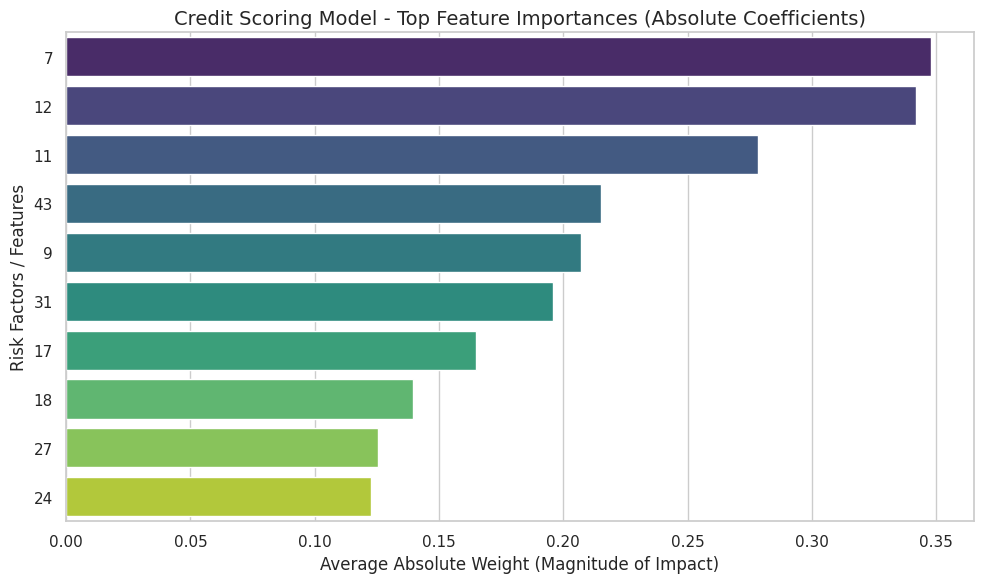

Calculating SHAP values...


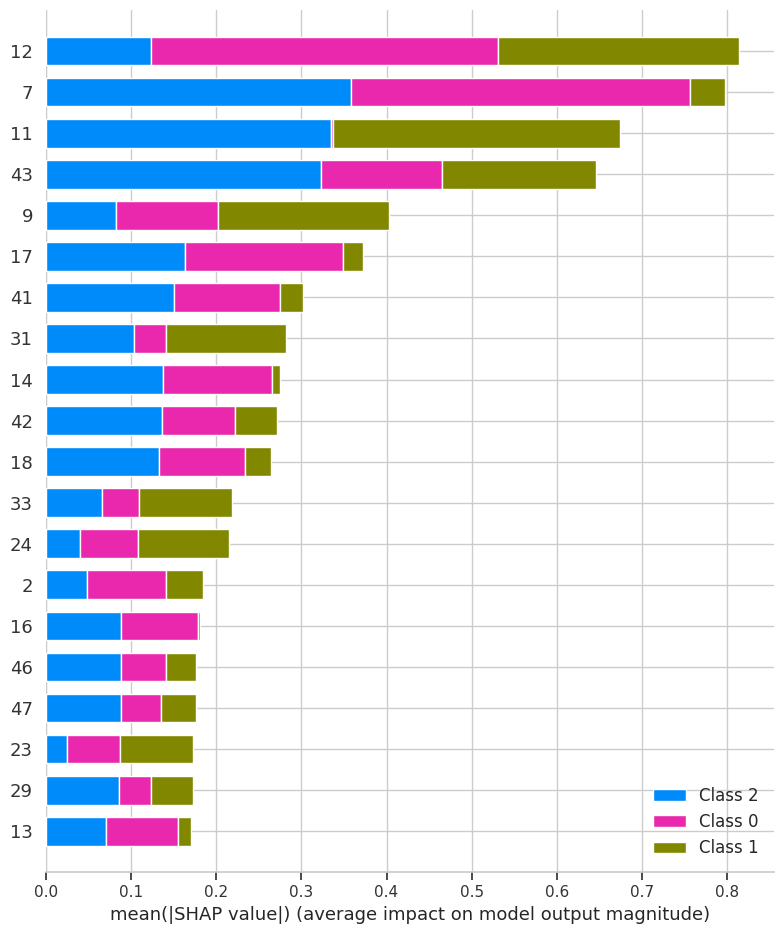

Generating Confusion Matrix...


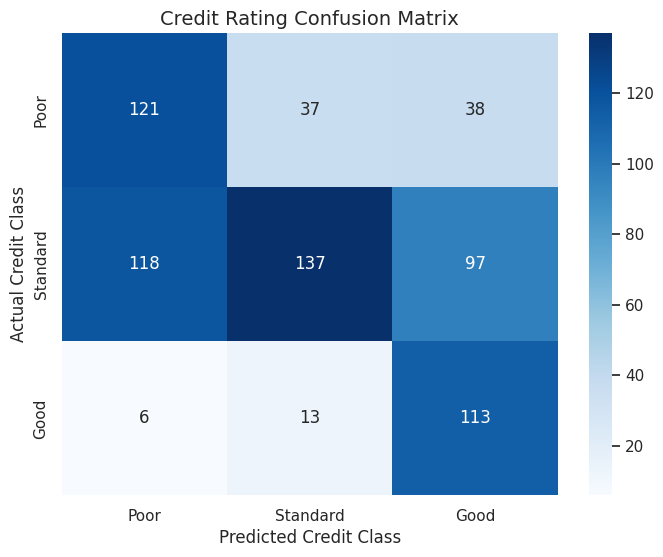


Classification Report:
               precision    recall  f1-score   support

        Poor       0.49      0.62      0.55       196
    Standard       0.73      0.39      0.51       352
        Good       0.46      0.86      0.59       132

    accuracy                           0.55       680
   macro avg       0.56      0.62      0.55       680
weighted avg       0.61      0.55      0.54       680



In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import shap

# =====================================================================
# CONNECT TO YOUR EXACT TRAINING VARIABLES
# =====================================================================
best_model = model                  # Uses your trained LogisticRegression model

# FIX: Force feature names to strings to prevent the TypeError 'int' has no len()
feature_names = [str(col) for col in X_full_df.columns]

# ==========================================
# 1. GLOBAL FEATURE IMPORTANCE PLOT
# ==========================================
print("Generating Feature Importance Plot from Coefficients...")

if best_model.coef_.ndim > 1:
    importances = np.mean(np.abs(best_model.coef_), axis=0)
else:
    importances = np.abs(best_model.coef_)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Credit Scoring Model - Top Feature Importances (Absolute Coefficients)")
sns.barplot(x=importances[indices][:10], y=[feature_names[i] for i in indices[:10]], palette="viridis")
plt.xlabel("Average Absolute Weight (Magnitude of Impact)")
plt.ylabel("Risk Factors / Features")
plt.tight_layout()
plt.show()

# ==========================================
# 2. SHAP VALUES (EXPLAINABILITY FOR LINEAR MODELS)
# ==========================================
print("Calculating SHAP values...")
# Initialize with a robust background dataset masker
masker = shap.maskers.Independent(X_train_resampled, max_samples=100)
explainer = shap.LinearExplainer(best_model, masker)

# Select validation sample
sample_size = min(500, X_val_scaled.shape[0])
X_sample = X_val_scaled[:sample_size]

# Wrap the numpy array into a DataFrame so SHAP inherently reads string features
X_sample_df = pd.DataFrame(X_sample, columns=feature_names)
shap_values = explainer(X_sample_df)

# Plot summary cleanly
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample_df)

# ==========================================
# 3. CONFUSION MATRIX REVIEW (ON VALIDATION SET)
# ==========================================
print("Generating Confusion Matrix...")
y_pred = best_model.predict(X_val_scaled)
cm = confusion_matrix(y_val, y_pred)

labels = ['Poor', 'Standard', 'Good']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Credit Rating Confusion Matrix')
plt.ylabel('Actual Credit Class')
plt.xlabel('Predicted Credit Class')
plt.show()

# Show text-based classification report
print("\nClassification Report:\n", classification_report(y_val, y_pred, target_names=labels))


In [33]:
import os
print("Current Directory:", os.getcwd())
print("Available Files:", os.listdir('.'))


Current Directory: /content
Available Files: ['.config', 'test.csv', 'train.csv', 'sample_data']


In [40]:
import pandas as pd
import numpy as np
from sklearn.base import clone
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------
# 1. Load the Data
# ---------------------------------------------------------
print("Loading raw datasets from /content...")
train_raw = pd.read_csv('/content/train.csv', low_memory=False)
test_raw = pd.read_csv('/content/test.csv', low_memory=False)

def clean_data(train, test):
    train_clean = train.copy()
    test_clean = test.copy()

    # 1. Convert known numerical columns first BEFORE touching string representations
    numeric_candidates = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
                          'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly',
                          'Monthly_Balance']
    for col in numeric_candidates:
        if col in train_clean.columns:
            train_clean[col] = pd.to_numeric(train_clean[col], errors='coerce')
        if col in test_clean.columns:
            test_clean[col] = pd.to_numeric(test_clean[col], errors='coerce')

    # 2. Define strict drop fields to avoid string corruption
    ignore_cols = ['Credit_Score', 'ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan']

    train_obj_cols = [c for c in train_clean.select_dtypes(include=['object']).columns if c not in ignore_cols]
    test_obj_cols = [c for c in test_clean.select_dtypes(include=['object']).columns if c not in ignore_cols]

    for col in train_obj_cols:
        train_clean[col] = train_clean[col].fillna('').astype(str).str.strip(' \t_')
    for col in test_obj_cols:
        test_clean[col] = test_clean[col].fillna('').astype(str).str.strip(' \t_')

    # 3. Encode category/text columns safely into numbers using training baseline categories
    categorical_cols = train_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if col not in ignore_cols:
            train_clean[col] = train_clean[col].astype('category')
            test_clean[col] = pd.Categorical(test_clean[col], categories=train_clean[col].cat.categories)

            train_clean[col] = train_clean[col].cat.codes
            test_clean[col] = test_clean[col].cat.codes

    # 4. Map the target strings to numeric values cleanly
    if 'Credit_Score' in train_clean.columns:
        target_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
        train_clean['Credit_Score'] = train_clean['Credit_Score'].astype(str).str.strip(' \t_').map(target_mapping)
        train_clean = train_clean.dropna(subset=['Credit_Score'])
        train_clean['Credit_Score'] = train_clean['Credit_Score'].astype(int)

    return train_clean, test_clean

print("Processing and cleaning data...")
train_df, test_df = clean_data(train_raw, test_raw)

# Separate features and target cleanly
target_col = 'Credit_Score'
columns_to_drop = [target_col, 'ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan']

# Find shared feature columns to ensure flawless alignment
feature_cols = [col for col in train_df.columns if col not in columns_to_drop]

X_train_full = train_df[feature_cols]
y_train_full = train_df[target_col]
X_test = test_df[feature_cols]  # Enforces identical ordering and column list

# =====================================================================
# Safety Step: Handling NA/INF values cleanly
# =====================================================================
print("Ensuring absolute zero NaN/inf values remain...")
X_train_full = X_train_full.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill NaNs with the proper mathematical baseline median
imputer = SimpleImputer(strategy='median')
X_train_full_clean = imputer.fit_transform(X_train_full)
X_test_clean = imputer.transform(X_test)

# ---------------------------------------------------------
# 2. Retrain the Optimized Model
# ---------------------------------------------------------
try:
    final_model = clone(best_model)
except NameError:
    print("❌ Error: 'best_model' is not defined. Please define or import your tuned model first.")
    raise

print("Retraining the optimized model on the full cleaned training dataset...")
final_model.fit(X_train_full_clean, y_train_full)
print("Model training complete.")

# ---------------------------------------------------------
# 3. Predict Credit Scores on Test Data
# ---------------------------------------------------------
print("Predicting credit scores for the test dataset...")
test_predictions = final_model.predict(X_test_clean)

if len(test_predictions.shape) > 1 and test_predictions.shape[1] == 1:
    test_predictions = test_predictions.ravel()

# ---------------------------------------------------------
# 4. Verify Class Proportions
# ---------------------------------------------------------
print("\n--- Verifying Class Proportions ---")
train_proportions = pd.Series(y_train_full).value_counts(normalize=True).sort_index()
test_proportions = pd.Series(test_predictions).value_counts(normalize=True).sort_index()

comparison_df = pd.DataFrame({
    'Train Proportions': train_proportions,
    'Predicted Test Proportions': test_proportions
})
print(comparison_df)

proportion_drift = (comparison_df['Train Proportions'] - comparison_df['Predicted Test Proportions']).abs().max()
if proportion_drift > 0.05:
    print(f"\n⚠️ Warning: Distribution drift detected! Max difference is {proportion_drift:.2%}.")
else:
    print(f"\n✅ Success: Predicted proportions closely align with training data (Max diff: {proportion_drift:.2%}).")

# ---------------------------------------------------------
# 5. Map 0/1/2 Target Codes Back to String Labels
# ---------------------------------------------------------
label_mapping = {0: 'Poor', 1: 'Standard', 2: 'Good'}
mapped_predictions = [label_mapping[code] for code in test_predictions]

# ---------------------------------------------------------
# 6. Export Submission File
# ---------------------------------------------------------
submission_df = pd.DataFrame({
    'ID': test_raw['ID'],
    'Credit_Score': mapped_predictions
})

assert len(submission_df) == len(test_raw), f"Error: Row count mismatch. Got {len(submission_df)} rows."
assert submission_df.isna().sum().sum() == 0, "Error: Submission file contains blank/NaN values."

submission_path = 'final_credit_score_submission.csv'
submission_df.to_csv(submission_path, index=False)
print(f"\n🚀 Complete! Successfully exported {len(submission_df)} rows to '{submission_path}'.")


Loading raw datasets from /content...
Processing and cleaning data...
Ensuring absolute zero NaN/inf values remain...
Retraining the optimized model on the full cleaned training dataset...
Model training complete.
Predicting credit scores for the test dataset...

--- Verifying Class Proportions ---
   Train Proportions  Predicted Test Proportions
0            0.28998                     0.35656
1            0.53174                     0.21296
2            0.17828                     0.43048

⚠️ Warning: Distribution drift detected! Max difference is 31.88%.

🚀 Complete! Successfully exported 50000 rows to 'final_credit_score_submission.csv'.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
